valid lines [4, 5, 7, 6, 0, 11, 12, 8, 1, 2, 13]
[[np.int64(8), np.int64(1), np.int64(0), np.int64(6), np.int64(7), np.int64(5), np.int64(4), np.int64(12), np.int64(11)], [np.int64(2), np.int64(13)]]
[[np.int32(9), np.int32(8), np.int32(1), np.int32(2), np.int32(7), np.int32(2), np.int32(6), np.int32(3), np.int32(5), np.int32(8)], [np.int32(1), np.int32(3), np.int32(4)]]
valid lines [10, 3]
[[np.int64(8), np.int64(1), np.int64(0), np.int64(6), np.int64(7), np.int64(5), np.int64(4), np.int64(12), np.int64(11)], [np.int64(2), np.int64(13)], [np.int64(3), np.int64(10)]]
[[np.int32(9), np.int32(8), np.int32(1), np.int32(2), np.int32(7), np.int32(2), np.int32(6), np.int32(3), np.int32(5), np.int32(8)], [np.int32(1), np.int32(3), np.int32(4)], [np.int32(3), np.int32(8), np.int32(6)]]
valid lines [9]
[[np.int64(8), np.int64(1), np.int64(0), np.int64(6), np.int64(7), np.int64(5), np.int64(4), np.int64(12), np.int64(11)], [np.int64(2), np.int64(13)], [np.int64(3), np.int64(10)], [np.int64(9)]]


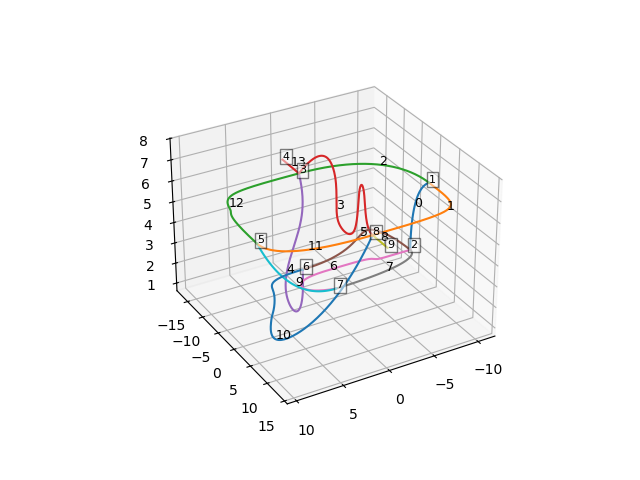

valid lines [4, 5, 7, 6, 0, 11, 12, 8, 1, 2, 13]
[[np.int64(8), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(0)], [np.int64(11), np.int64(12), np.int64(13)]]
[[np.int32(9), np.int32(8), np.int32(1), np.int32(3), np.int32(6), np.int32(2), np.int32(7), np.int32(2), np.int32(1)], [np.int32(8), np.int32(5), np.int32(3), np.int32(4)]]
valid lines [10, 3]
[[np.int64(8), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(0)], [np.int64(11), np.int64(12), np.int64(13)], [np.int64(3), np.int64(10)]]
[[np.int32(9), np.int32(8), np.int32(1), np.int32(3), np.int32(6), np.int32(2), np.int32(7), np.int32(2), np.int32(1)], [np.int32(8), np.int32(5), np.int32(3), np.int32(4)], [np.int32(3), np.int32(8), np.int32(6)]]
valid lines [9]
[[np.int64(8), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(0)], [np.int64(11), np.int64(12), np.int64(13)], [np.int64(3), np.int64(10)], [np.int64(9)]]


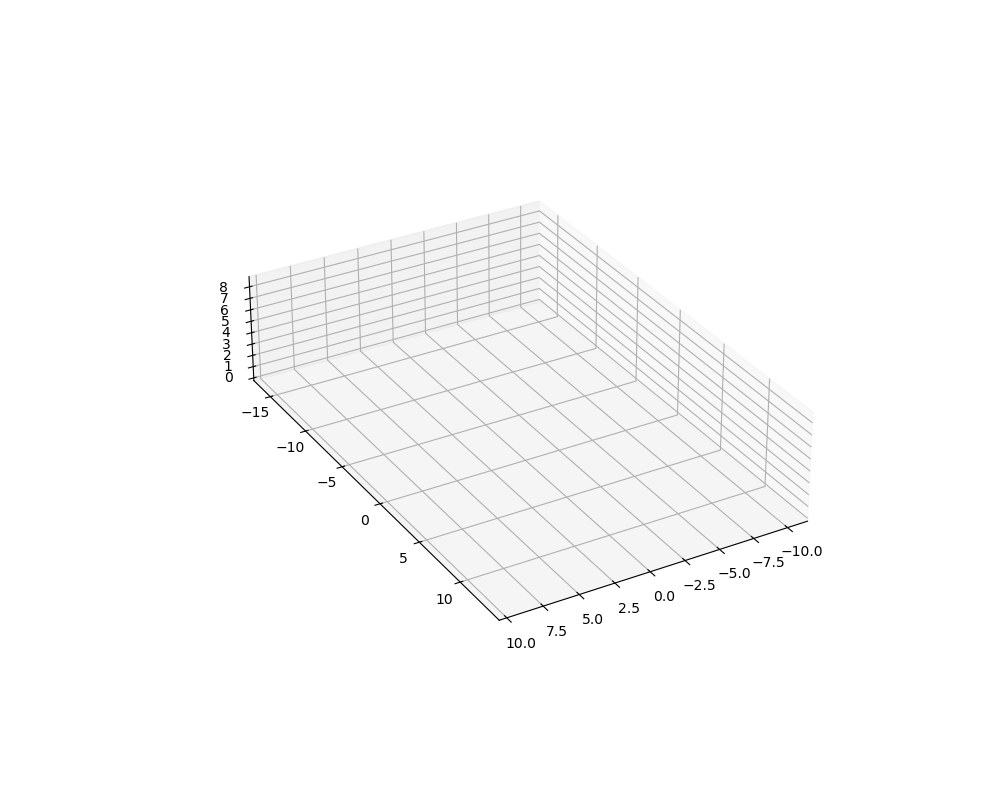

In [ ]:
%matplotlib widget

from fracprint import processor_NEW as processor
from fracprint import writer_NEW as writer


# File settings

filedir  = "./Rhino/"
filename = "newvesselbranched.txt"
fileout  = "graph_check.gcode"


# Base print settings

d = 0.8
x_offset, y_offset = 0, 0          # CALIBRATE
bed_temperature = 0
floor = -26                        # CALIBRATE
z_min = -25                        # CALIBRATE
roof = 0
f_print = 200
E_clean = 10


# Node overshoot settings
node_settings = {
    # NUDGE (processor-stage)
    "node_nudge_mm": 0,
    "node_nudge_npts": 0,

    # SLOWDOWN ON REVISIT (writer-stage)
    "node_slow_dist_mm": 0,
    "f_node": f_print,
    "node_tol": 0.1,                 # matching tolerance for shared nodes 
    "slow_revisit_start": False,     # slow if a line STARTS at a revisited node too

    # Dwell at node
    "node_dwell_ms": 0, #in ms up to 300 ms should be sufficient
}


# Build settings
settings = processor.build_settings(
    filedir, filename, fileout,
    d, x_offset, y_offset,
    bed_temperature, floor, z_min, roof,
    f_print, E_clean
)

# Add node settings BEFORE preprocessing
settings.update(node_settings)


# Preprocess geometry (processor)
df, line_order_grouped = processor.shape_prep(settings)

# Write gcode (writer)
df_print = writer.gcode_writer(df, settings, line_order_grouped)

# Animation
data_frame, terminal_points, nodes = processor.node_finder(df)
eline_order, enode_order, eline_order_grouped, enode_order_grouped = processor.eulerficator(
    data_frame, terminal_points, nodes
)
ani = processor.node_plotter(
    data_frame, terminal_points, eline_order, enode_order, enode_order_grouped
)